# Lumbar Spinal MRI Classification — BYOL Self-Supervised Pretraining


## Install Dependencies

In [1]:
!pip install -q timm

## Configuration

In [2]:
from pathlib import Path

SEED = 42
DATASET_ZIP = None
EXPECTED_CLASSES = ['Herniated Disc', 'No Stenosis', 'Thecal Sac']
EXPECTED_TOTAL_IMAGES = 13686

TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10

INPUT_SIZE = 224
BATCH_SIZE = 32          # supervised fine-tuning stage batch size
HEAD_EPOCHS = 5          # linear-probe (frozen backbone) epochs during fine-tuning
FINE_TUNE_EPOCHS = 25    # full fine-tuning epochs

HEAD_LR = 3e-4
BACKBONE_LR = 1e-5
FINE_TUNE_HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.40
LABEL_SMOOTHING = 0.05
PATIENCE = 8
MIN_DELTA = 1e-4

REMOVE_EXACT_DUPLICATES = True
RESUME_IF_AVAILABLE = True   # both pretraining and fine-tuning are resumable
EXPERIMENT_ID = 'lumbar_mri_byol_224_bs32_v1'

OUTPUT_DIR = Path('/kaggle/working') / EXPERIMENT_ID
EXTRACT_DIR = OUTPUT_DIR / 'extracted_dataset'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
FIGURE_DIR = OUTPUT_DIR / 'paper_figures'
TABLE_DIR = OUTPUT_DIR / 'tables'

# Same three architectures, same timm identifiers as the supervised notebooks
# (VGG16 / ResNet50 from the 6-model notebook, ConvNeXt Small from its own
# notebook) so the BYOL numbers line up with the supervised numbers exactly.
MODEL_SPECS = {
    'VGG16': {'timm_name': 'vgg16.tv_in1k'},
    'ResNet50': {'timm_name': 'resnet50.tv_in1k'},
    'ConvNeXtSmall': {'timm_name': 'convnext_small.fb_in22k_ft_in1k'},
}
MODELS_TO_RUN = list(MODEL_SPECS)

# ---- BYOL-specific configuration ----
METHOD_NAME = 'BYOL'
PRETRAINED_INIT = True        # see markdown above: True = domain-adaptive BYOL from ImageNet weights
BYOL_PRETRAIN_EPOCHS = 30     # raise if you have time budget, lower (e.g. 15) if you are tight on time
BYOL_BATCH_SIZE = 32
BYOL_BACKBONE_LR = 5e-5   
BYOL_HEAD_LR = 1e-3       
BYOL_WARMUP_STEPS_RATIO = 0.05
BYOL_WEIGHT_DECAY = 1.5e-6
BYOL_BASE_MOMENTUM = 0.996    # EMA momentum for the target network, cosine-annealed to 1.0
BYOL_HIDDEN_DIM = 2048        # projector/predictor MLP hidden size (paper default is 4096; reduced for time budget)
BYOL_PROJECTION_DIM = 256
BYOL_CROP_SCALE = (0.6, 1.0)  # RandomResizedCrop scale range for the two BYOL views


## Imports and Reproducibility

In [3]:
import gc
import hashlib
import itertools
import json
import math
import os
import random
import shutil
import time
import warnings
import zipfile
from concurrent.futures import ThreadPoolExecutor
from contextlib import nullcontext

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageFile
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True

for path in [OUTPUT_DIR, EXTRACT_DIR, CHECKPOINT_DIR, FIGURE_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = DEVICE.type == 'cuda'

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'timm: {timm.__version__}')


Device: cuda
PyTorch: 2.10.0+cu128
timm: 1.0.26


## Dataset Discovery

In [4]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
SEARCH_ROOTS = [Path('/kaggle/input'), Path('/mnt/data')]
DATASET_KEYWORDS = ('lumbar', 'lumber', 'spinal', 'stenosis')


def zip_score(path):
    name = path.name.lower()
    keyword_score = sum(keyword in name for keyword in DATASET_KEYWORDS)
    return keyword_score * 10_000_000 + path.stat().st_size


def discover_zip():
    if DATASET_ZIP is not None:
        path = Path(DATASET_ZIP)
        if not path.exists():
            raise FileNotFoundError(f'DATASET_ZIP does not exist: {path}')
        return path

    candidates = []
    for root in SEARCH_ROOTS:
        if root.exists():
            candidates.extend(root.rglob('*.zip'))

    candidates = [
        path for path in candidates
        if any(keyword in path.name.lower() for keyword in DATASET_KEYWORDS)
    ]
    return max(candidates, key=zip_score) if candidates else None


def class_image_folders(root):
    folders = []
    for current, dirs, _ in os.walk(root):
        current_path = Path(current)
        if current_path.name in EXPECTED_CLASSES:
            has_images = any(
                path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
                for path in current_path.iterdir()
            )
            if has_images:
                folders.append(current_path)
            dirs[:] = []
    return folders


def discover_image_root():
    archive = discover_zip()
    if archive is not None:
        marker = EXTRACT_DIR / '.extracted'
        signature = f'{archive}:{archive.stat().st_size}'
        if not marker.exists() or marker.read_text().strip() != signature:
            if EXTRACT_DIR.exists():
                shutil.rmtree(EXTRACT_DIR)
            EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(archive) as zipped:
                zipped.extractall(EXTRACT_DIR)
            marker.write_text(signature)
        return EXTRACT_DIR, archive

    for root in SEARCH_ROOTS:
        if root.exists() and class_image_folders(root):
            return root, None

    raise FileNotFoundError('The Lumbar Spinal MRI dataset was not found.')


DATA_ROOT, ARCHIVE_PATH = discover_image_root()
CLASS_FOLDERS = class_image_folders(DATA_ROOT)
found_classes = sorted({folder.name for folder in CLASS_FOLDERS})

if found_classes != sorted(EXPECTED_CLASSES):
    raise ValueError(f'Expected {EXPECTED_CLASSES}, but found {found_classes}')

print(f'Archive: {ARCHIVE_PATH}')
print(f'Data root: {DATA_ROOT}')
print(f'Class folders: {len(CLASS_FOLDERS)}')


Archive: None
Data root: /kaggle/input
Class folders: 6


## Dataset Audit and Duplicate Control

In [5]:
def infer_original_split(path):
    lowered = [part.lower() for part in Path(path).parts]
    for split_name in ['train', 'validation', 'valid', 'val', 'test']:
        if split_name in lowered:
            return split_name
    return 'unspecified'


def inspect_image(path):
    try:
        with open(path, 'rb') as file:
            content = file.read()

        digest = hashlib.sha256(content).hexdigest()

        with Image.open(path) as image:
            width, height = image.size
            mode = image.mode
            image.verify()

        return str(path), True, digest, width, height, mode, ''
    except Exception as exc:
        return str(path), False, '', np.nan, np.nan, '', str(exc)


records = []
for folder in sorted(CLASS_FOLDERS, key=lambda path: (path.name, str(path))):
    for path in sorted(folder.iterdir()):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            records.append({
                'path': str(path),
                'class_name': folder.name,
                'original_split': infer_original_split(path),
            })

raw_df = pd.DataFrame(records)
if raw_df.empty:
    raise RuntimeError('No images were found.')

with ThreadPoolExecutor(max_workers=max(2, NUM_WORKERS * 2)) as executor:
    audit_rows = list(tqdm(
        executor.map(inspect_image, raw_df['path']),
        total=len(raw_df),
        desc='Auditing images',
    ))

audit_df = pd.DataFrame(
    audit_rows,
    columns=['path', 'valid', 'sha256', 'width', 'height', 'mode', 'error'],
)

raw_df = raw_df.merge(audit_df, on='path', how='left')
valid_df = raw_df[raw_df['valid']].copy()
invalid_df = raw_df[~raw_df['valid']].copy()
invalid_df.to_csv(TABLE_DIR / 'invalid_images.csv', index=False)

cross_class_groups = (
    valid_df.groupby('sha256')['class_name']
    .nunique()
    .loc[lambda values: values > 1]
)

if len(cross_class_groups):
    raise RuntimeError('Identical images were found under different class labels.')

before_counts = valid_df['class_name'].value_counts().reindex(EXPECTED_CLASSES)

if REMOVE_EXACT_DUPLICATES:
    cleaned_df = valid_df.drop_duplicates('sha256', keep='first').copy()
else:
    cleaned_df = valid_df.copy()

cleaned_df = cleaned_df.sort_values(['class_name', 'path']).reset_index(drop=True)
after_counts = cleaned_df['class_name'].value_counts().reindex(EXPECTED_CLASSES)
duplicate_count = len(valid_df) - len(cleaned_df)

class_names = sorted(cleaned_df['class_name'].unique())
class_to_index = {name: index for index, name in enumerate(class_names)}
cleaned_df['label'] = cleaned_df['class_name'].map(class_to_index).astype(int)

audit_summary = pd.DataFrame({
    'Before deduplication': before_counts,
    'After deduplication': after_counts,
})

original_split_summary = pd.crosstab(
    valid_df['original_split'],
    valid_df['class_name'],
).reindex(columns=class_names, fill_value=0)

audit_summary.to_csv(TABLE_DIR / 'dataset_audit_summary.csv')
original_split_summary.to_csv(TABLE_DIR / 'original_split_distribution.csv')
cleaned_df.to_csv(TABLE_DIR / 'cleaned_dataset_manifest.csv', index=False)

print(f'Original images: {len(raw_df):,}')
print(f'Invalid images: {len(invalid_df):,}')
print(f'Exact duplicate copies removed: {duplicate_count:,}')
print(f'Retained images: {len(cleaned_df):,}')

if len(raw_df) != EXPECTED_TOTAL_IMAGES:
    print(f'Warning: expected {EXPECTED_TOTAL_IMAGES:,} images, found {len(raw_df):,}.')

display(audit_summary)
display(original_split_summary)


Auditing images:   0%|          | 0/13686 [00:00<?, ?it/s]

Original images: 13,686
Invalid images: 0
Exact duplicate copies removed: 650
Retained images: 13,036


,Before deduplication,After deduplication
class_name,,
Herniated Disc,4281,4215
No Stenosis,4659,4400
Thecal Sac,4746,4421


class_name,Herniated Disc,No Stenosis,Thecal Sac
original_split,,,
test,1218,1507,13
train,3063,3152,4733


## Stratified 70/20/10 Split

In [6]:
if not math.isclose(TRAIN_RATIO + VAL_RATIO + TEST_RATIO, 1.0):
    raise ValueError('TRAIN_RATIO + VAL_RATIO + TEST_RATIO must equal 1.0')

train_df, remaining_df = train_test_split(
    cleaned_df,
    test_size=VAL_RATIO + TEST_RATIO,
    stratify=cleaned_df['label'],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    remaining_df,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=remaining_df['label'],
    random_state=SEED,
)

train_df = train_df.sort_values(['label', 'path']).reset_index(drop=True)
val_df = val_df.sort_values(['label', 'path']).reset_index(drop=True)
test_df = test_df.sort_values(['label', 'path']).reset_index(drop=True)

for name, frame in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    frame.to_csv(TABLE_DIR / f'{name}_split.csv', index=False)

train_hashes = set(train_df['sha256'])
val_hashes = set(val_df['sha256'])
test_hashes = set(test_df['sha256'])

if train_hashes & val_hashes or train_hashes & test_hashes or val_hashes & test_hashes:
    raise RuntimeError('Exact-copy leakage was detected between splits.')

split_table = pd.DataFrame({
    'Training': train_df['class_name'].value_counts().reindex(class_names),
    'Validation': val_df['class_name'].value_counts().reindex(class_names),
    'Test': test_df['class_name'].value_counts().reindex(class_names),
}).astype(int)

split_table.loc['Total'] = split_table.sum()
split_table.to_csv(TABLE_DIR / 'class_distribution_after_split.csv')

display(split_table)
print(f'Training: {len(train_df):,} ({len(train_df) / len(cleaned_df):.2%})  <- used UNLABELED for BYOL pretraining, then WITH labels for fine-tuning')
print(f'Validation: {len(val_df):,} ({len(val_df) / len(cleaned_df):.2%})  <- labels used only for early stopping during fine-tuning')
print(f'Test: {len(test_df):,} ({len(test_df) / len(cleaned_df):.2%})  <- touched once, for final evaluation only')


,Training,Validation,Test
class_name,,,
Herniated Disc,2950,843,422
No Stenosis,3080,880,440
Thecal Sac,3095,884,442
Total,9125,2607,1304


Training: 9,125 (70.00%)  <- used UNLABELED for BYOL pretraining, then WITH labels for fine-tuning
Validation: 2,607 (20.00%)  <- labels used only for early stopping during fine-tuning
Test: 1,304 (10.00%)  <- touched once, for final evaluation only


## MRI Preprocessing and Labeled Data Pipeline

In [7]:
def save_figure(fig, stem):
    fig.savefig(
        FIGURE_DIR / f'{stem}.png',
        dpi=400,
        bbox_inches='tight',
        facecolor='white',
    )
    fig.savefig(
        FIGURE_DIR / f'{stem}.pdf',
        bbox_inches='tight',
        facecolor='white',
    )


class MRIPreprocess:
    def __init__(self, threshold=10, lower_percentile=1.0, upper_percentile=99.0, padding=0.04):
        self.threshold = threshold
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.padding = padding

    def __call__(self, image):
        gray = np.asarray(image.convert('L'), dtype=np.uint8)

        foreground_mask = gray > self.threshold
        if foreground_mask.any():
            rows, columns = np.where(foreground_mask)
            top, bottom = rows.min(), rows.max() + 1
            left, right = columns.min(), columns.max() + 1

            vertical_padding = max(2, int((bottom - top) * self.padding))
            horizontal_padding = max(2, int((right - left) * self.padding))

            top = max(0, top - vertical_padding)
            bottom = min(gray.shape[0], bottom + vertical_padding)
            left = max(0, left - horizontal_padding)
            right = min(gray.shape[1], right + horizontal_padding)

            gray = gray[top:bottom, left:right]

        foreground = gray[gray > self.threshold]
        if foreground.size > 10:
            lower, upper = np.percentile(
                foreground,
                [self.lower_percentile, self.upper_percentile],
            )
            if upper > lower:
                gray = np.clip(
                    (gray.astype(np.float32) - lower) * 255.0 / (upper - lower),
                    0,
                    255,
                ).astype(np.uint8)

        height, width = gray.shape
        side = max(height, width)
        canvas = np.zeros((side, side), dtype=np.uint8)
        top = (side - height) // 2
        left = (side - width) // 2
        canvas[top:top + height, left:left + width] = gray

        return Image.fromarray(canvas, mode='L').convert('RGB')


class MRIFrameDataset(Dataset):
    """Labeled dataset — used ONLY for the supervised fine-tuning stage."""

    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row['path']) as image:
            image = image.copy()
        return self.transform(image), int(row['label']), row['path']


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def make_transforms(mean, std):
    deterministic_preprocess = MRIPreprocess()

    train_transform = transforms.Compose([
        deterministic_preprocess,
        transforms.Resize(
            (INPUT_SIZE, INPUT_SIZE),
            interpolation=InterpolationMode.BICUBIC,
            antialias=True,
        ),
        transforms.RandomAffine(
            degrees=6,
            translate=(0.03, 0.03),
            scale=(0.97, 1.03),
            interpolation=InterpolationMode.BILINEAR,
            fill=0,
        ),
        transforms.RandomApply([
            transforms.ColorJitter(brightness=0.05, contrast=0.08),
        ], p=0.50),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    eval_transform = transforms.Compose([
        deterministic_preprocess,
        transforms.Resize(
            (INPUT_SIZE, INPUT_SIZE),
            interpolation=InterpolationMode.BICUBIC,
            antialias=True,
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    return train_transform, eval_transform


def make_loaders(mean, std):
    """Labeled loaders for the fine-tuning stage (train_df/val_df/test_df, WITH labels)."""
    train_transform, eval_transform = make_transforms(mean, std)
    generator = torch.Generator().manual_seed(SEED)

    common = {
        'num_workers': NUM_WORKERS,
        'pin_memory': PIN_MEMORY,
        'persistent_workers': NUM_WORKERS > 0,
        'worker_init_fn': seed_worker,
    }

    train_loader = DataLoader(
        MRIFrameDataset(train_df, train_transform),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        **common,
    )

    val_loader = DataLoader(
        MRIFrameDataset(val_df, eval_transform),
        batch_size=BATCH_SIZE,
        shuffle=False,
        **common,
    )

    test_loader = DataLoader(
        MRIFrameDataset(test_df, eval_transform),
        batch_size=BATCH_SIZE,
        shuffle=False,
        **common,
    )

    return train_loader, val_loader, test_loader


weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=train_df['label'].to_numpy(),
)

class_weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

class_weight_table = pd.DataFrame({
    'Class': class_names,
    'Weight': weights,
})

class_weight_table.to_csv(TABLE_DIR / 'class_weights.csv', index=False)
display(class_weight_table)


,Class,Weight
0,Herniated Disc,1.031073
1,No Stenosis,0.987554
2,Thecal Sac,0.982768


## BYOL Unlabeled Pretraining Pipeline

In [8]:
class BYOLPretrainDataset(Dataset):
    """Unlabeled dataset for BYOL pretraining. Only uses image paths — no labels."""

    def __init__(self, frame, transform_1, transform_2):
        self.paths = frame['path'].tolist()  # labels intentionally never stored/used here
        self.transform_1 = transform_1
        self.transform_2 = transform_2

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        with Image.open(path) as image:
            image = image.copy()
        return self.transform_1(image), self.transform_2(image)


def make_byol_transforms(mean, std):
    preprocess = MRIPreprocess()

    def common_augment():
        return [
            transforms.RandomResizedCrop(
                INPUT_SIZE,
                scale=BYOL_CROP_SCALE,
                interpolation=InterpolationMode.BICUBIC,
                antialias=True,
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([
                transforms.RandomAffine(
                    degrees=8,
                    translate=(0.04, 0.04),
                    scale=(0.95, 1.05),
                    interpolation=InterpolationMode.BILINEAR,
                    fill=0,
                ),
            ], p=0.5),
            transforms.RandomApply([
                transforms.ColorJitter(brightness=0.3, contrast=0.3),
            ], p=0.8),
        ]

    view_1 = transforms.Compose([
        preprocess,
        *common_augment(),
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
        ], p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    view_2 = transforms.Compose([
        preprocess,
        *common_augment(),
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
        ], p=0.1),
        transforms.RandomSolarize(threshold=128, p=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    return view_1, view_2


def make_byol_loader(mean, std):
    view_1, view_2 = make_byol_transforms(mean, std)
    dataset = BYOLPretrainDataset(train_df, view_1, view_2)
    generator = torch.Generator().manual_seed(SEED)

    loader = DataLoader(
        dataset,
        batch_size=BYOL_BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
        generator=generator,
        drop_last=True,   # keeps BatchNorm1d in the projector/predictor happy
    )
    return dataset, loader


## BYOL Model: Online / Target Networks


In [9]:
class MLPHead(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


def byol_loss_fn(pred, target):
    pred = F.normalize(pred, dim=-1, p=2)
    target = F.normalize(target, dim=-1, p=2)
    return 2 - 2 * (pred * target).sum(dim=-1)


class BYOL(nn.Module):
    def __init__(self, online_backbone, backbone_fn, feature_dim, hidden_dim, proj_dim):
        super().__init__()
        self.online_backbone = online_backbone
        self.online_projector = MLPHead(feature_dim, hidden_dim, proj_dim)
        self.predictor = MLPHead(proj_dim, hidden_dim, proj_dim)

        self.target_backbone = backbone_fn()
        self.target_projector = MLPHead(feature_dim, hidden_dim, proj_dim)

        self.target_backbone.load_state_dict(self.online_backbone.state_dict())
        self.target_projector.load_state_dict(self.online_projector.state_dict())

        for parameter in itertools.chain(
            self.target_backbone.parameters(),
            self.target_projector.parameters(),
        ):
            parameter.requires_grad = False

    @torch.no_grad()
    def update_target(self, momentum):
        for online_module, target_module in [
            (self.online_backbone, self.target_backbone),
            (self.online_projector, self.target_projector),
        ]:
            for online_p, target_p in zip(online_module.parameters(), target_module.parameters()):
                target_p.data.mul_(momentum).add_(online_p.data, alpha=1 - momentum)

            for online_b, target_b in zip(online_module.buffers(), target_module.buffers()):
                if online_b.dtype.is_floating_point:
                    target_b.data.mul_(momentum).add_(online_b.data, alpha=1 - momentum)
                else:
                    target_b.data.copy_(online_b.data)

    def forward(self, view_a, view_b):
        online_pred_a = self.predictor(self.online_projector(self.online_backbone(view_a)))
        online_pred_b = self.predictor(self.online_projector(self.online_backbone(view_b)))

        with torch.no_grad():
            target_proj_a = self.target_projector(self.target_backbone(view_a))
            target_proj_b = self.target_projector(self.target_backbone(view_b))

        loss_a = byol_loss_fn(online_pred_a, target_proj_b.detach())
        loss_b = byol_loss_fn(online_pred_b, target_proj_a.detach())
        return (loss_a + loss_b).mean()


def build_byol(model_label):
    timm_name = MODEL_SPECS[model_label]['timm_name']
    config = timm.get_pretrained_cfg(timm_name)

    if config is None:
        raise RuntimeError(f'No pretrained configuration was found for {timm_name}')

    def backbone_fn():
        return timm.create_model(
            timm_name,
            pretrained=PRETRAINED_INIT,
            num_classes=0,
            global_pool='avg',
        )

    online_backbone = backbone_fn()
    feature_dim = int(
        online_backbone.head_hidden_size
        if hasattr(online_backbone, 'head_hidden_size')
        else online_backbone.num_features
    )

    byol = BYOL(
        online_backbone,
        backbone_fn,
        feature_dim,
        hidden_dim=BYOL_HIDDEN_DIM,
        proj_dim=BYOL_PROJECTION_DIM,
    )

    mean = tuple(config.mean)
    std = tuple(config.std)
    return byol, timm_name, feature_dim, mean, std


def momentum_schedule(step, total_steps, base_momentum=BYOL_BASE_MOMENTUM):
    progress = min(max(step / max(total_steps, 1), 0.0), 1.0)
    return 1 - (1 - base_momentum) * (math.cos(math.pi * progress) + 1) / 2


model_overview = pd.DataFrame([
    {
        'Model': model_label,
        'timm identifier': MODEL_SPECS[model_label]['timm_name'],
        'Input size': f'{INPUT_SIZE} x {INPUT_SIZE}',
        'BYOL batch size': BYOL_BATCH_SIZE,
        'BYOL pretrain epochs': BYOL_PRETRAIN_EPOCHS,
    }
    for model_label in MODELS_TO_RUN
])
display(model_overview)


,Model,timm identifier,Input size,BYOL batch size,BYOL pretrain epochs
0,VGG16,vgg16.tv_in1k,224 x 224,32,30
1,ResNet50,resnet50.tv_in1k,224 x 224,32,30
2,ConvNeXtSmall,convnext_small.fb_in22k_ft_in1k,224 x 224,32,30


## Shared Training Utilities (AMP, checkpoint I/O)

In [10]:
def autocast_context(training=True):
    if USE_AMP and training:
        return torch.autocast(device_type='cuda', dtype=torch.float16)
    return nullcontext()


def make_scaler():
    try:
        return torch.amp.GradScaler('cuda', enabled=USE_AMP)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=USE_AMP)


def load_checkpoint(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


## BYOL Pretraining Loop (resumable, per-epoch checkpointing)


VGG16: BYOL self-supervised pretraining (unlabeled)


model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

VGG16 BYOL pretrain epoch 1/30:   0%|          | 0/285 [00:00<?, ?it/s]

VGG16 | BYOL pretrain | epoch 01/30 | loss 0.9842 | skipped batches so far: 0


VGG16 BYOL pretrain epoch 2/30:   0%|          | 0/285 [00:00<?, ?it/s]

...

VGG16 | BYOL pretrain | epoch 28/30 | loss 0.0615 | skipped batches so far: 0


VGG16 BYOL pretrain epoch 29/30:   0%|          | 0/285 [00:00<?, ?it/s]

VGG16 | BYOL pretrain | epoch 29/30 | loss 0.0613 | skipped batches so far: 0


VGG16 BYOL pretrain epoch 30/30:   0%|          | 0/285 [00:00<?, ?it/s]

VGG16 | BYOL pretrain | epoch 30/30 | loss 0.0614 | skipped batches so far: 0
VGG16: BYOL pretraining finished in 151.5 min.


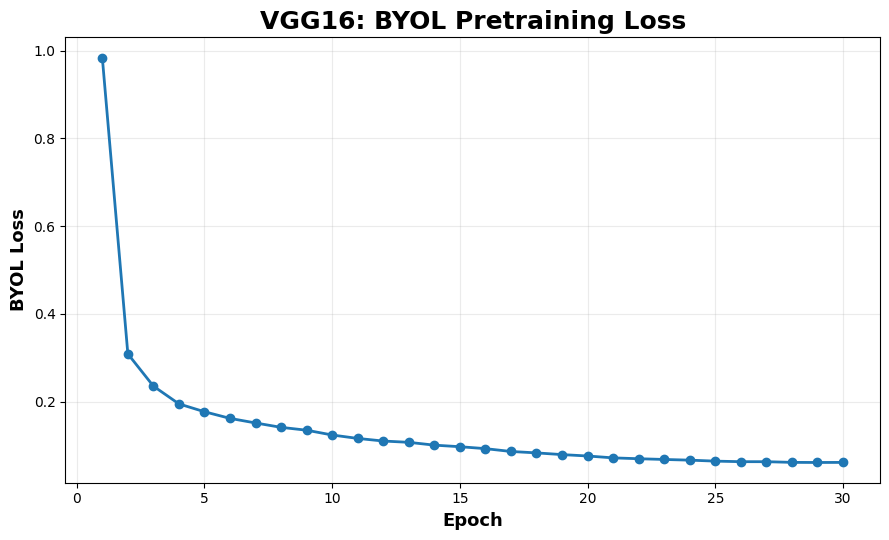


ResNet50: BYOL self-supervised pretraining (unlabeled)


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet50 BYOL pretrain epoch 1/30:   0%|          | 0/285 [00:00<?, ?it/s]

ResNet50 | BYOL pretrain | epoch 01/30 | loss 1.2020 | skipped batches so far: 0


ResNet50 BYOL pretrain epoch 2/30:   0%|          | 0/285 [00:00<?, ?it/s]

...

ResNet50 | BYOL pretrain | epoch 28/30 | loss 0.0676 | skipped batches so far: 0


ResNet50 BYOL pretrain epoch 29/30:   0%|          | 0/285 [00:00<?, ?it/s]

ResNet50 | BYOL pretrain | epoch 29/30 | loss 0.0673 | skipped batches so far: 0


ResNet50 BYOL pretrain epoch 30/30:   0%|          | 0/285 [00:00<?, ?it/s]

ResNet50 | BYOL pretrain | epoch 30/30 | loss 0.0669 | skipped batches so far: 0
ResNet50: BYOL pretraining finished in 135.8 min.


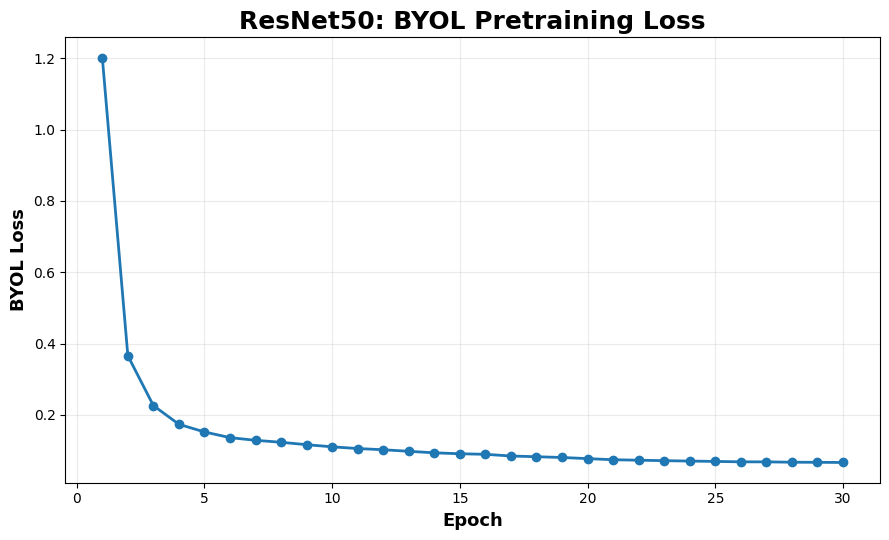


ConvNeXtSmall: BYOL self-supervised pretraining (unlabeled)


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

ConvNeXtSmall BYOL pretrain epoch 1/30:   0%|          | 0/285 [00:00<?, ?it/s]

ConvNeXtSmall | BYOL pretrain | epoch 01/30 | loss 1.0264 | skipped batches so far: 0


ConvNeXtSmall BYOL pretrain epoch 2/30:   0%|          | 0/285 [00:00<?, ?it/s]

...

ConvNeXtSmall | BYOL pretrain | epoch 28/30 | loss 0.0764 | skipped batches so far: 0


ConvNeXtSmall BYOL pretrain epoch 29/30:   0%|          | 0/285 [00:00<?, ?it/s]

ConvNeXtSmall | BYOL pretrain | epoch 29/30 | loss 0.0764 | skipped batches so far: 0


ConvNeXtSmall BYOL pretrain epoch 30/30:   0%|          | 0/285 [00:00<?, ?it/s]

ConvNeXtSmall | BYOL pretrain | epoch 30/30 | loss 0.0764 | skipped batches so far: 0
ConvNeXtSmall: BYOL pretraining finished in 148.0 min.


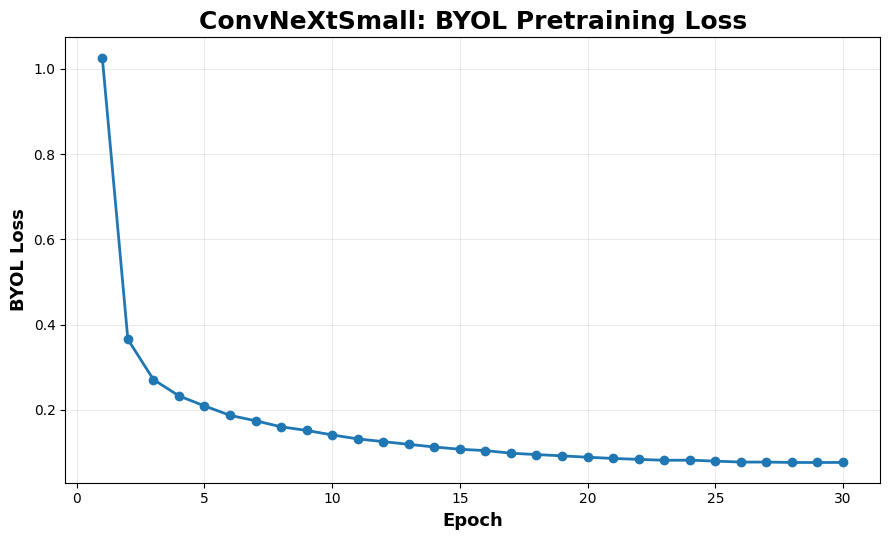

In [11]:
def pretrain_byol(model_label):
    backbone_ckpt = CHECKPOINT_DIR / f'{model_label.lower()}_byol_backbone.pth'
    state_ckpt = CHECKPOINT_DIR / f'{model_label.lower()}_byol_state.pth'
    history_path = TABLE_DIR / f'{model_label.lower()}_byol_pretrain_history.csv'

    if RESUME_IF_AVAILABLE and backbone_ckpt.exists():
        payload = load_checkpoint(backbone_ckpt, DEVICE)
        if payload.get('experiment_id') == EXPERIMENT_ID:
            print(f'{model_label}: BYOL pretraining already completed, reusing saved backbone.')
            return backbone_ckpt

    byol, timm_name, feature_dim, mean, std = build_byol(model_label)
    byol = byol.to(DEVICE)

    pretrain_dataset, pretrain_loader = make_byol_loader(mean, std)
    steps_per_epoch = len(pretrain_loader)
    total_steps = max(steps_per_epoch * BYOL_PRETRAIN_EPOCHS, 1)
    warmup_steps = max(int(total_steps * BYOL_WARMUP_STEPS_RATIO), 1)

    backbone_parameters = list(byol.online_backbone.parameters())
    head_parameters = list(byol.online_projector.parameters()) + list(byol.predictor.parameters())
    online_parameters = backbone_parameters + head_parameters

    optimizer = torch.optim.AdamW([
        {'params': backbone_parameters, 'lr': BYOL_BACKBONE_LR},
        {'params': head_parameters, 'lr': BYOL_HEAD_LR},
    ], weight_decay=BYOL_WEIGHT_DECAY)

    base_lrs = [group['lr'] for group in optimizer.param_groups]

    def lr_at(step):
        if step < warmup_steps:
            return [lr * (step + 1) / warmup_steps for lr in base_lrs]
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        progress = min(max(progress, 0.0), 1.0)
        return [lr * 0.5 * (1 + math.cos(math.pi * progress)) for lr in base_lrs]

    scaler = make_scaler()

    history = []
    start_epoch = 0
    global_step = 0
    skipped_batches = 0

    if RESUME_IF_AVAILABLE and state_ckpt.exists():
        state = load_checkpoint(state_ckpt, DEVICE)
        if state.get('experiment_id') == EXPERIMENT_ID and state.get('model_label') == model_label:
            byol.load_state_dict(state['byol_state_dict'])
            optimizer.load_state_dict(state['optimizer_state_dict'])
            start_epoch = state['epoch']
            global_step = state['global_step']
            history = state['history']
            print(f'{model_label}: resuming BYOL pretraining from epoch {start_epoch}.')

    if start_epoch < BYOL_PRETRAIN_EPOCHS:
        training_start = time.perf_counter()

        for epoch in range(start_epoch, BYOL_PRETRAIN_EPOCHS):
            byol.train()
            running_loss = 0.0
            seen = 0
            progress = tqdm(
                pretrain_loader,
                leave=False,
                desc=f'{model_label} BYOL pretrain epoch {epoch + 1}/{BYOL_PRETRAIN_EPOCHS}',
            )

            for view_a, view_b in progress:
                view_a = view_a.to(DEVICE, non_blocking=True)
                view_b = view_b.to(DEVICE, non_blocking=True)

                momentum = momentum_schedule(global_step, total_steps)
                for group, lr in zip(optimizer.param_groups, lr_at(global_step)):
                    group['lr'] = lr

                optimizer.zero_grad(set_to_none=True)
                with autocast_context(True):
                    loss = byol(view_a, view_b)

                if not torch.isfinite(loss):
                    skipped_batches += 1
                    print(f'{model_label}: non-finite loss at step {global_step}, skipping this batch '
                          f'({skipped_batches} skipped so far).')
                    optimizer.zero_grad(set_to_none=True)
                    global_step += 1
                    continue

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(online_parameters, max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

                byol.update_target(momentum)

                running_loss += loss.item() * view_a.size(0)
                seen += view_a.size(0)
                global_step += 1
                progress.set_postfix(loss=f'{loss.item():.4f}', m=f'{momentum:.5f}')

            epoch_loss = running_loss / max(seen, 1)
            history.append({'epoch': epoch + 1, 'loss': epoch_loss})

            print(
                f'{model_label} | BYOL pretrain | epoch {epoch + 1:02d}/{BYOL_PRETRAIN_EPOCHS} | '
                f'loss {epoch_loss:.4f} | skipped batches so far: {skipped_batches}'
            )

            torch.save({
                'experiment_id': EXPERIMENT_ID,
                'model_label': model_label,
                'epoch': epoch + 1,
                'global_step': global_step,
                'byol_state_dict': byol.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
            }, state_ckpt)

        training_seconds = time.perf_counter() - training_start
        print(f'{model_label}: BYOL pretraining finished in {training_seconds / 60:.1f} min.')
    else:
        print(f'{model_label}: BYOL pretraining already complete at epoch {start_epoch}.')

    torch.save({
        'experiment_id': EXPERIMENT_ID,
        'model_label': model_label,
        'timm_name': timm_name,
        'backbone_state_dict': byol.online_backbone.state_dict(),
        'feature_dim': feature_dim,
        'mean': mean,
        'std': std,
        'pretrained_init': PRETRAINED_INIT,
    }, backbone_ckpt)

    history_frame = pd.DataFrame(history)
    history_frame.to_csv(history_path, index=False)

    fig, axis = plt.subplots(figsize=(9, 5.5))
    axis.plot(history_frame['epoch'], history_frame['loss'], marker='o', linewidth=2)
    axis.set_title(f'{model_label}: BYOL Pretraining Loss', fontsize=18, fontweight='bold')
    axis.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axis.set_ylabel('BYOL Loss', fontsize=13, fontweight='bold')
    axis.grid(alpha=0.25)
    fig.tight_layout()
    save_figure(fig, f'byol_pretrain_loss_{model_label.lower()}')
    plt.show()

    byol.to('cpu')
    del byol, optimizer
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    return backbone_ckpt


for model_label in MODELS_TO_RUN:
    print('\n' + '=' * 88)
    print(f'{model_label}: BYOL self-supervised pretraining (unlabeled)')
    print('=' * 88)
    pretrain_byol(model_label)

## Supervised Fine-Tuning on the BYOL Backbones

In [12]:
class TransferClassifier(nn.Module):
    def __init__(self, timm_name, num_classes, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(
            timm_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg',
        )
        feature_count = int(
            self.backbone.head_hidden_size
            if hasattr(self.backbone, 'head_hidden_size')
            else self.backbone.num_features
        )
        self.classifier = nn.Sequential(
            nn.Dropout(DROPOUT),
            nn.Linear(feature_count, num_classes),
        )

    def forward(self, inputs):
        features = self.backbone(inputs)
        return self.classifier(features)


def build_finetune_model(model_label):
    backbone_ckpt = CHECKPOINT_DIR / f'{model_label.lower()}_byol_backbone.pth'
    if not backbone_ckpt.exists():
        raise FileNotFoundError(
            f'No BYOL backbone checkpoint found for {model_label}. Run pretraining first.'
        )

    payload = load_checkpoint(backbone_ckpt, DEVICE)
    timm_name = payload['timm_name']

    model = TransferClassifier(timm_name, len(class_names), pretrained=False)
    model.backbone.load_state_dict(payload['backbone_state_dict'], strict=True)

    mean = payload['mean']
    std = payload['std']
    return model, timm_name, mean, std


def freeze_batchnorm(model):
    for module in model.backbone.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()
            for parameter in module.parameters():
                parameter.requires_grad = False


def configure_stage(model, stage):
    if stage == 'head':
        for parameter in model.backbone.parameters():
            parameter.requires_grad = False
        for parameter in model.classifier.parameters():
            parameter.requires_grad = True
    else:
        for parameter in model.parameters():
            parameter.requires_grad = True


def make_optimizer(model, stage):
    if stage == 'head':
        return torch.optim.AdamW(
            model.classifier.parameters(),
            lr=HEAD_LR,
            weight_decay=WEIGHT_DECAY,
        )

    return torch.optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': BACKBONE_LR},
        {'params': model.classifier.parameters(), 'lr': FINE_TUNE_HEAD_LR},
    ], weight_decay=WEIGHT_DECAY)


def run_epoch(model, loader, criterion, optimizer=None, scaler=None, stage='fine_tune'):
    training = optimizer is not None
    model.train(training)

    if training and stage == 'head':
        model.backbone.eval()

    if training and stage == 'fine_tune':
        freeze_batchnorm(model)

    running_loss = 0.0
    labels_all = []
    predictions_all = []

    progress = tqdm(loader, leave=False, desc='Training' if training else 'Validation')

    for images, labels, _ in progress:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with autocast_context(training):
                logits = model(images)
                loss = criterion(logits, labels)

            if not torch.isfinite(logits).all():
                raise RuntimeError(f'Non-finite logits during {"training" if training else "validation"}.')
            if not torch.isfinite(loss):
                raise RuntimeError(f'Non-finite loss during {"training" if training else "validation"}.')

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()

        running_loss += loss.item() * labels.size(0)
        labels_all.extend(labels.detach().cpu().numpy())
        predictions_all.extend(logits.argmax(dim=1).detach().cpu().numpy())
        progress.set_postfix(loss=f'{loss.item():.4f}')

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(labels_all, predictions_all)
    epoch_f1 = f1_score(labels_all, predictions_all, average='macro', zero_division=0)

    return epoch_loss, epoch_accuracy, epoch_f1


def save_history_plot(history, model_label):
    frame = pd.DataFrame(history)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

    axes[0].plot(frame['epoch'], frame['train_loss'], marker='o', linewidth=2, label='Train Loss')
    axes[0].plot(frame['epoch'], frame['val_loss'], marker='o', linewidth=2, label='Validation Loss')
    axes[0].set_title('Training and Validation Loss', fontsize=18, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Loss', fontsize=13, fontweight='bold')
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=11)

    axes[1].plot(frame['epoch'], frame['train_accuracy'], marker='o', linewidth=2, label='Train Accuracy')
    axes[1].plot(frame['epoch'], frame['val_accuracy'], marker='o', linewidth=2, label='Validation Accuracy')
    axes[1].set_title('Training and Validation Accuracy', fontsize=18, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Accuracy', fontsize=13, fontweight='bold')
    axes[1].set_ylim(0, 1.02)
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=11)

    fine_tune_epochs = frame.loc[frame['stage'] == 'fine_tune', 'epoch']
    if len(fine_tune_epochs):
        fine_tune_start = fine_tune_epochs.min()
        for axis in axes:
            axis.axvline(fine_tune_start - 0.5, linestyle='--', linewidth=1.5, label='Fine-tuning starts')

    fig.suptitle(f'{model_label}: BYOL Fine-Tuning History', fontsize=22, fontweight='bold', y=1.02)
    fig.tight_layout()
    save_figure(fig, f'finetune_history_{model_label.lower()}')
    plt.show()


def train_finetune_model(model_label):
    checkpoint_path = CHECKPOINT_DIR / f'{model_label.lower()}_byol_finetuned_best.pth'
    history_path = TABLE_DIR / f'{model_label.lower()}_byol_finetune_history.csv'
    metadata_path = TABLE_DIR / f'{model_label.lower()}_byol_finetune_training.json'

    model, timm_name, mean, std = build_finetune_model(model_label)
    model = model.to(DEVICE)

    train_loader, val_loader, test_loader = make_loaders(mean, std)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
    scaler = make_scaler()

    history = []
    best_score = -np.inf
    best_val_loss = np.inf
    best_epoch = 0
    global_epoch = 0
    training_start = time.perf_counter()

    stages = [('head', HEAD_EPOCHS), ('fine_tune', FINE_TUNE_EPOCHS)]

    for stage, stage_epochs in stages:
        if stage == 'fine_tune' and checkpoint_path.exists():
            checkpoint = load_checkpoint(checkpoint_path, DEVICE)
            model.load_state_dict(checkpoint['model_state_dict'])

        configure_stage(model, stage)
        optimizer = make_optimizer(model, stage)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-7,
        )
        patience_count = 0

        for _ in range(stage_epochs):
            global_epoch += 1

            train_loss, train_accuracy, train_f1 = run_epoch(
                model, train_loader, criterion, optimizer, scaler, stage,
            )
            val_loss, val_accuracy, val_f1 = run_epoch(model, val_loader, criterion)

            scheduler.step(val_f1)
            learning_rates = [group['lr'] for group in optimizer.param_groups]

            history.append({
                'epoch': global_epoch,
                'stage': stage,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'train_accuracy': train_accuracy,
                'val_accuracy': val_accuracy,
                'train_f1': train_f1,
                'val_f1': val_f1,
                'learning_rate': max(learning_rates),
            })

            improved = (
                val_f1 > best_score + MIN_DELTA
                or (abs(val_f1 - best_score) <= MIN_DELTA and val_loss < best_val_loss)
            )

            if improved:
                best_score = val_f1
                best_val_loss = val_loss
                best_epoch = global_epoch
                patience_count = 0

                torch.save({
                    'experiment_id': EXPERIMENT_ID,
                    'model_state_dict': model.state_dict(),
                    'model_label': model_label,
                    'timm_name': timm_name,
                    'class_names': class_names,
                    'mean': mean,
                    'std': std,
                    'input_size': INPUT_SIZE,
                    'batch_size': BATCH_SIZE,
                    'best_epoch': best_epoch,
                    'best_val_f1': float(best_score),
                    'best_val_loss': float(best_val_loss),
                }, checkpoint_path)
            else:
                patience_count += 1

            print(
                f'{model_label} | {stage} | epoch {global_epoch:02d} | '
                f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
                f'train acc {train_accuracy:.4f} | val acc {val_accuracy:.4f}'
            )

            if stage == 'fine_tune' and patience_count >= PATIENCE:
                print(f'Early stopping at epoch {global_epoch}.')
                break

    training_seconds = time.perf_counter() - training_start
    best_checkpoint = load_checkpoint(checkpoint_path, DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])

    history_frame = pd.DataFrame(history)
    history_frame.to_csv(history_path, index=False)

    metadata = {
        'experiment_id': EXPERIMENT_ID,
        'model': model_label,
        'timm_name': timm_name,
        'input_size': INPUT_SIZE,
        'batch_size': BATCH_SIZE,
        'head_epochs': HEAD_EPOCHS,
        'fine_tune_epochs': FINE_TUNE_EPOCHS,
        'best_epoch': best_epoch,
        'best_val_f1': float(best_score),
        'best_val_loss': float(best_val_loss),
        'training_seconds': float(training_seconds),
    }

    metadata_path.write_text(json.dumps(metadata, indent=2))
    save_history_plot(history, model_label)

    return model, val_loader, test_loader, metadata


## Evaluation Utilities

In [13]:
def predict_classes(model, loader):
    model.eval()
    labels_all = []
    predictions_all = []
    paths_all = []
    start = time.perf_counter()

    with torch.no_grad():
        for images, labels, paths in tqdm(loader, leave=False, desc='Predicting'):
            images = images.to(DEVICE, non_blocking=True)

            with autocast_context(False):
                logits = model(images)

            predictions = logits.argmax(dim=1).cpu().numpy()
            labels_all.append(labels.numpy())
            predictions_all.append(predictions)
            paths_all.extend(paths)

    elapsed = time.perf_counter() - start

    return (
        np.concatenate(labels_all),
        np.concatenate(predictions_all),
        np.asarray(paths_all),
        elapsed,
    )


def calculate_metrics(y_true, y_pred):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'f1_score': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
    }


def plot_confusion_matrix(matrix, model_label):
    fig, axis = plt.subplots(figsize=(8.8, 7.5))
    image = axis.imshow(matrix, interpolation='nearest', cmap='Blues')
    colorbar = fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    colorbar.ax.tick_params(labelsize=12)

    threshold = matrix.max() / 2 if matrix.size else 0

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = int(matrix[row, column])
            axis.text(
                column, row, str(value),
                ha='center', va='center', fontsize=21, fontweight='bold',
                color='white' if value > threshold else 'black',
            )

    axis.set_xticks(np.arange(len(class_names)))
    axis.set_yticks(np.arange(len(class_names)))
    axis.set_xticklabels(class_names, rotation=18, ha='right', fontsize=14, fontweight='bold')
    axis.set_yticklabels(class_names, fontsize=14, fontweight='bold')
    axis.set_xlabel('Predicted Label', fontsize=17, fontweight='bold', labelpad=12)
    axis.set_ylabel('True Label', fontsize=17, fontweight='bold', labelpad=12)
    axis.set_title(f'BYOL-{model_label} Confusion Matrix', fontsize=23, fontweight='bold', pad=16)

    fig.tight_layout()
    save_figure(fig, f'confusion_matrix_byol_{model_label.lower()}')
    plt.show()


def save_evaluation(model_label, model, test_loader, metadata):
    y_true, y_pred, paths, inference_seconds = predict_classes(model, test_loader)

    metrics = calculate_metrics(y_true, y_pred)
    metrics.update({
        'experiment_id': EXPERIMENT_ID,
        'model': f'BYOL-{model_label}',
        'input_size': INPUT_SIZE,
        'batch_size': BATCH_SIZE,
        'best_epoch': metadata['best_epoch'],
        'training_seconds': metadata['training_seconds'],
        'inference_ms_per_image': float(inference_seconds * 1000 / len(y_true)),
    })

    report = classification_report(
        y_true, y_pred, labels=np.arange(len(class_names)),
        target_names=class_names, output_dict=True, zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(TABLE_DIR / f'byol_{model_label.lower()}_classification_report.csv')

    pd.DataFrame({
        'path': paths,
        'true_label': [class_names[index] for index in y_true],
        'predicted_label': [class_names[index] for index in y_pred],
    }).to_csv(TABLE_DIR / f'byol_{model_label.lower()}_test_predictions.csv', index=False)

    (TABLE_DIR / f'byol_{model_label.lower()}_metrics.json').write_text(json.dumps(metrics, indent=2))

    matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    plot_confusion_matrix(matrix, model_label)

    return metrics


def completed_metrics(model_label):
    checkpoint_path = CHECKPOINT_DIR / f'{model_label.lower()}_byol_finetuned_best.pth'
    metrics_path = TABLE_DIR / f'byol_{model_label.lower()}_metrics.json'

    if not RESUME_IF_AVAILABLE:
        return None

    if checkpoint_path.exists() and metrics_path.exists():
        metrics = json.loads(metrics_path.read_text())
        if metrics.get('experiment_id') == EXPERIMENT_ID:
            return metrics

    return None


## Train and Evaluate BYOL-VGG16, BYOL-ResNet50, BYOL-ConvNeXt Small


BYOL-VGG16


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

VGG16 | head | epoch 01 | train loss 8.6040 | val loss 4.1213 | train acc 0.4016 | val acc 0.4661


Training:   0%|          | 0/286 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

VGG16 | fine_tune | epoch 29 | train loss 0.1824 | val loss 0.2800 | train acc 1.0000 | val acc 0.9655


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

VGG16 | fine_tune | epoch 30 | train loss 0.1822 | val loss 0.2826 | train acc 1.0000 | val acc 0.9632


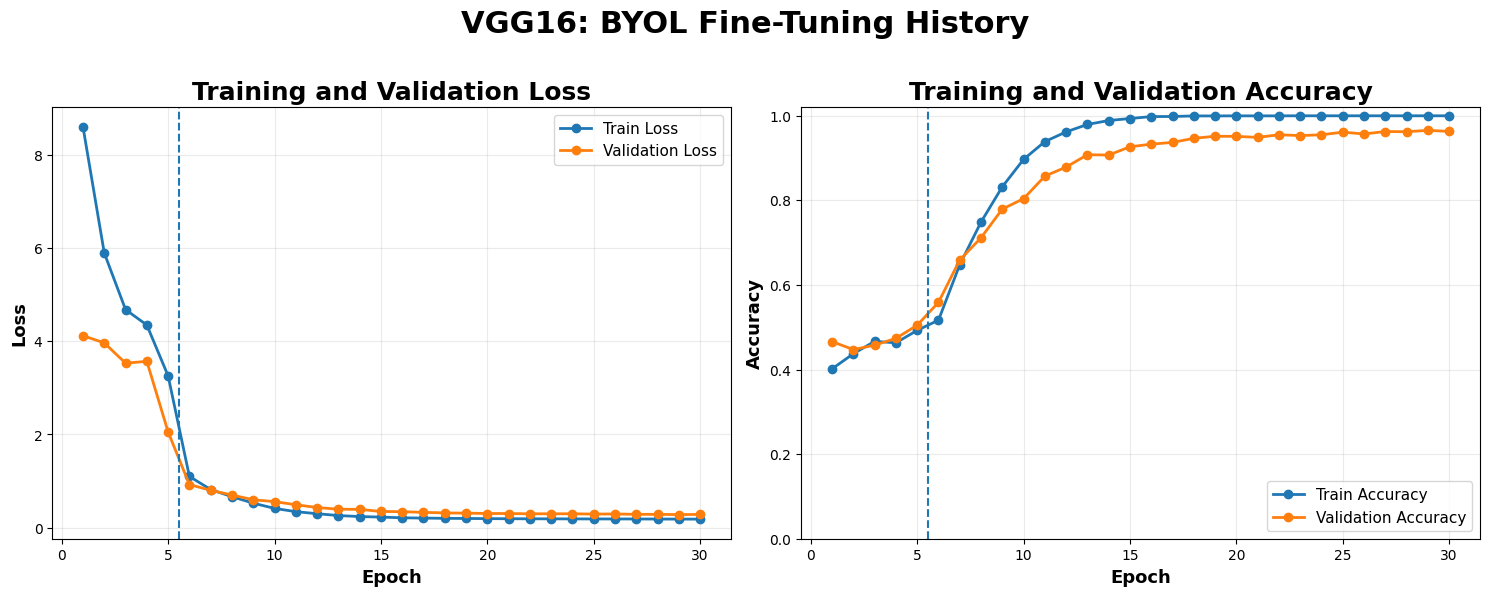

Predicting:   0%|          | 0/41 [00:00<?, ?it/s]

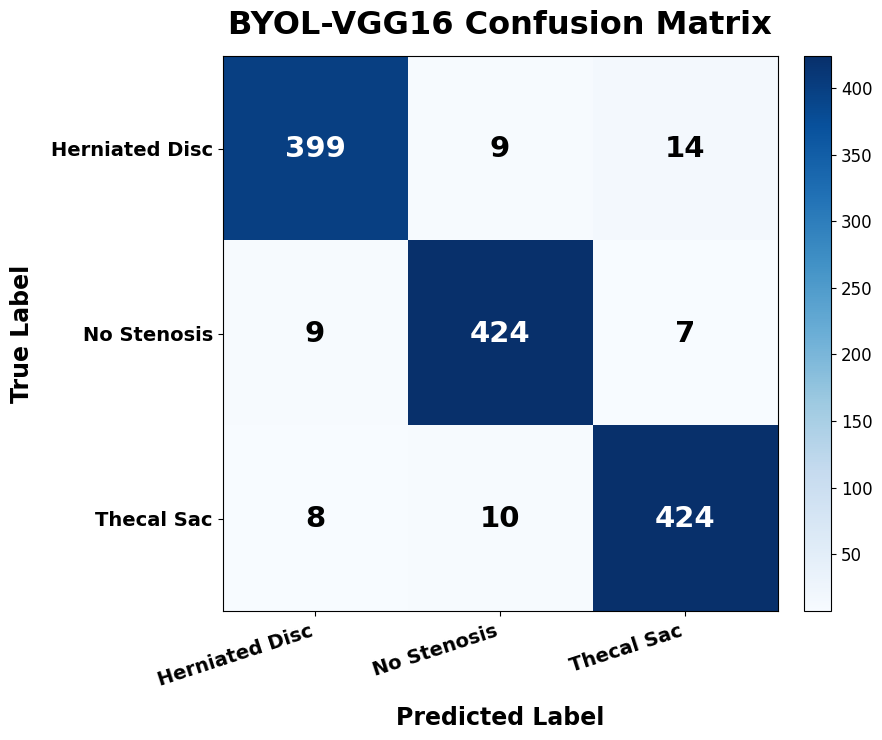

,Accuracy,Precision,Recall,F1 Score
Model,,,,
BYOL-VGG16,0.956288,0.956351,0.956137,0.95622



BYOL-ResNet50


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ResNet50 | head | epoch 01 | train loss 1.0825 | val loss 1.0464 | train acc 0.4061 | val acc 0.4657


...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ResNet50 | fine_tune | epoch 29 | train loss 0.1990 | val loss 0.3400 | train acc 0.9995 | val acc 0.9313


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ResNet50 | fine_tune | epoch 30 | train loss 0.1993 | val loss 0.3618 | train acc 0.9992 | val acc 0.9141


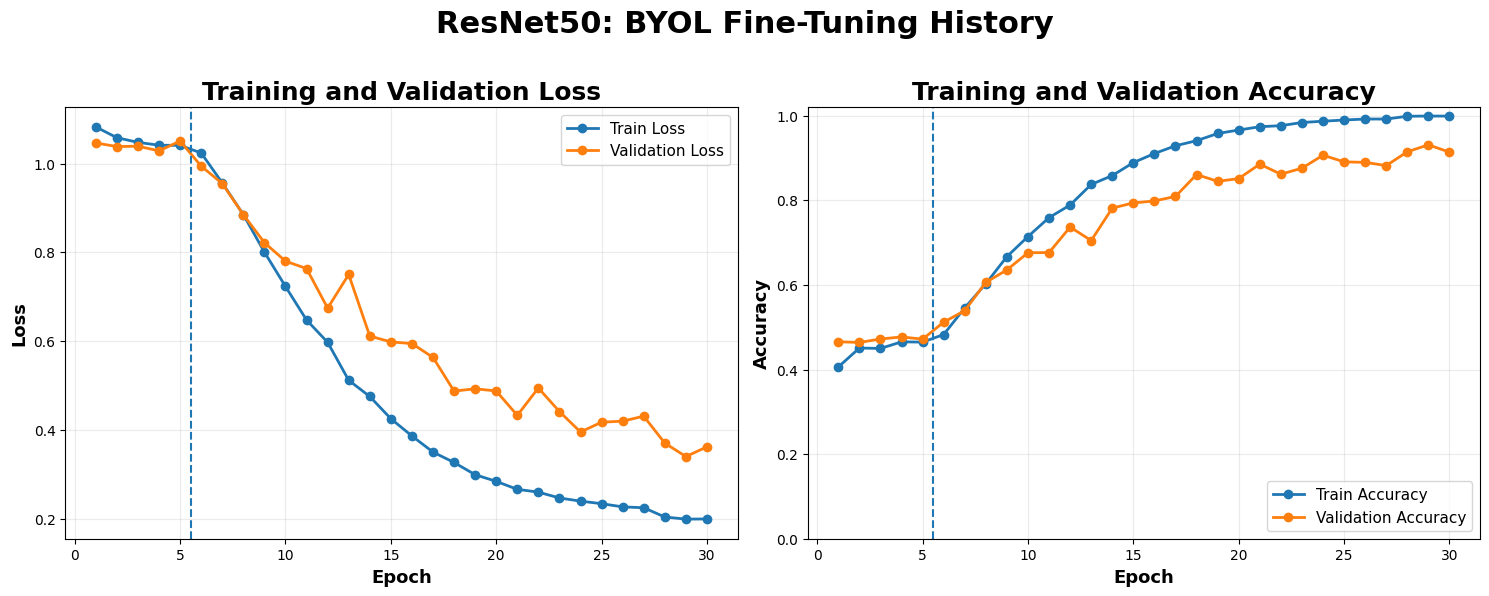

Predicting:   0%|          | 0/41 [00:00<?, ?it/s]

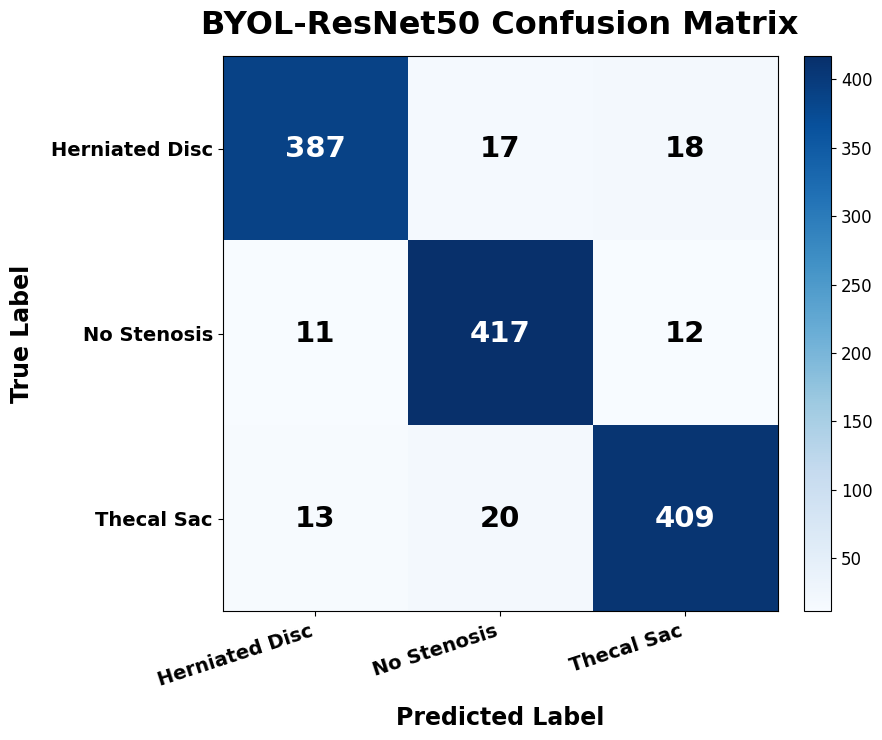

,Accuracy,Precision,Recall,F1 Score
Model,,,,
BYOL-ResNet50,0.930215,0.93059,0.930043,0.930183



BYOL-ConvNeXtSmall


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | head | epoch 01 | train loss 1.1359 | val loss 1.0458 | train acc 0.3909 | val acc 0.4641


...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | fine_tune | epoch 29 | train loss 0.1786 | val loss 0.4443 | train acc 1.0000 | val acc 0.8734


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | fine_tune | epoch 30 | train loss 0.1774 | val loss 0.4396 | train acc 1.0000 | val acc 0.8746


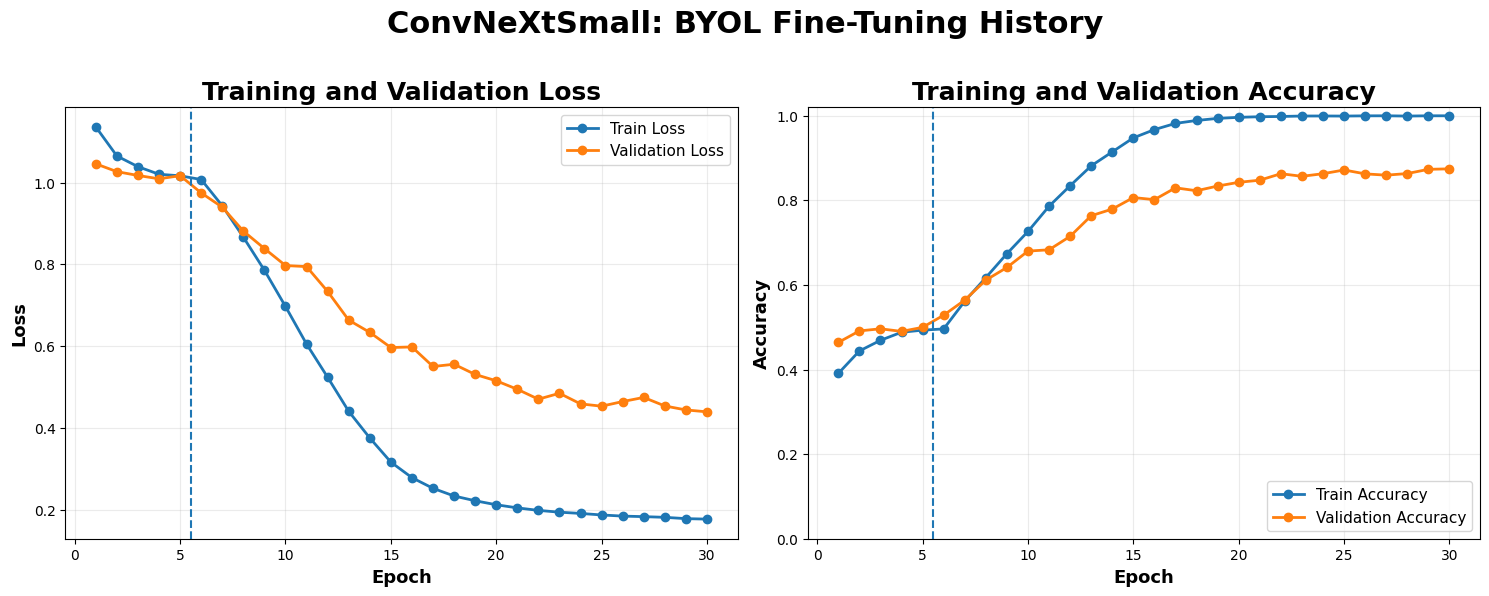

Predicting:   0%|          | 0/41 [00:00<?, ?it/s]

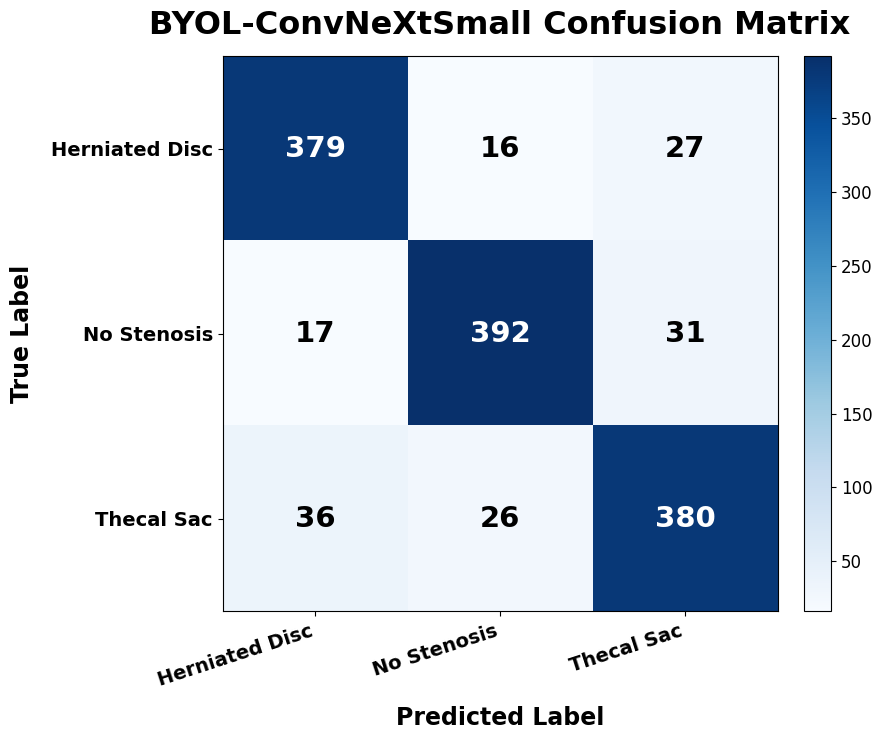

,Accuracy,Precision,Recall,F1 Score
Model,,,,
BYOL-ConvNeXtSmall,0.882669,0.882707,0.882914,0.88275


In [14]:
all_metrics = []

for model_label in MODELS_TO_RUN:
    print('\n' + '=' * 88)
    print(f'BYOL-{model_label}')
    print('=' * 88)

    saved = completed_metrics(model_label)

    if saved is not None:
        print('Loaded completed result for the current experiment configuration.')
        all_metrics.append(saved)
        continue

    model, val_loader, test_loader, metadata = train_finetune_model(model_label)
    metrics = save_evaluation(model_label, model, test_loader, metadata)

    all_metrics.append(metrics)

    display(pd.DataFrame([{
        'Model': f'BYOL-{model_label}',
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 Score': metrics['f1_score'],
    }]).set_index('Model'))

    model.to('cpu')
    del model, val_loader, test_loader
    gc.collect()

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


## Model Comparison

In [15]:
comparison = (
    pd.DataFrame(all_metrics)
    .sort_values('f1_score', ascending=False)
    .reset_index(drop=True)
)

comparison_table = comparison[['model', 'accuracy', 'precision', 'recall', 'f1_score']].copy()
comparison_table.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']

comparison_table.to_csv(TABLE_DIR / 'byol_model_comparison.csv', index=False)
(TABLE_DIR / 'byol_model_comparison.tex').write_text(
    comparison_table.to_latex(index=False, float_format='%.4f')
)

display(comparison_table)


,Model,Accuracy,Precision,Recall,F1 Score
0,BYOL-VGG16,0.956288,0.956351,0.956137,0.956220
1,BYOL-ResNet50,0.930215,0.930590,0.930043,0.930183
2,BYOL-ConvNeXtSmall,0.882669,0.882707,0.882914,0.882750


## Explainable AI: Grad-CAM and Occlusion Sensitivity


Explainability: BYOL-VGG16


Selecting XAI samples:   0%|          | 0/41 [00:00<?, ?it/s]

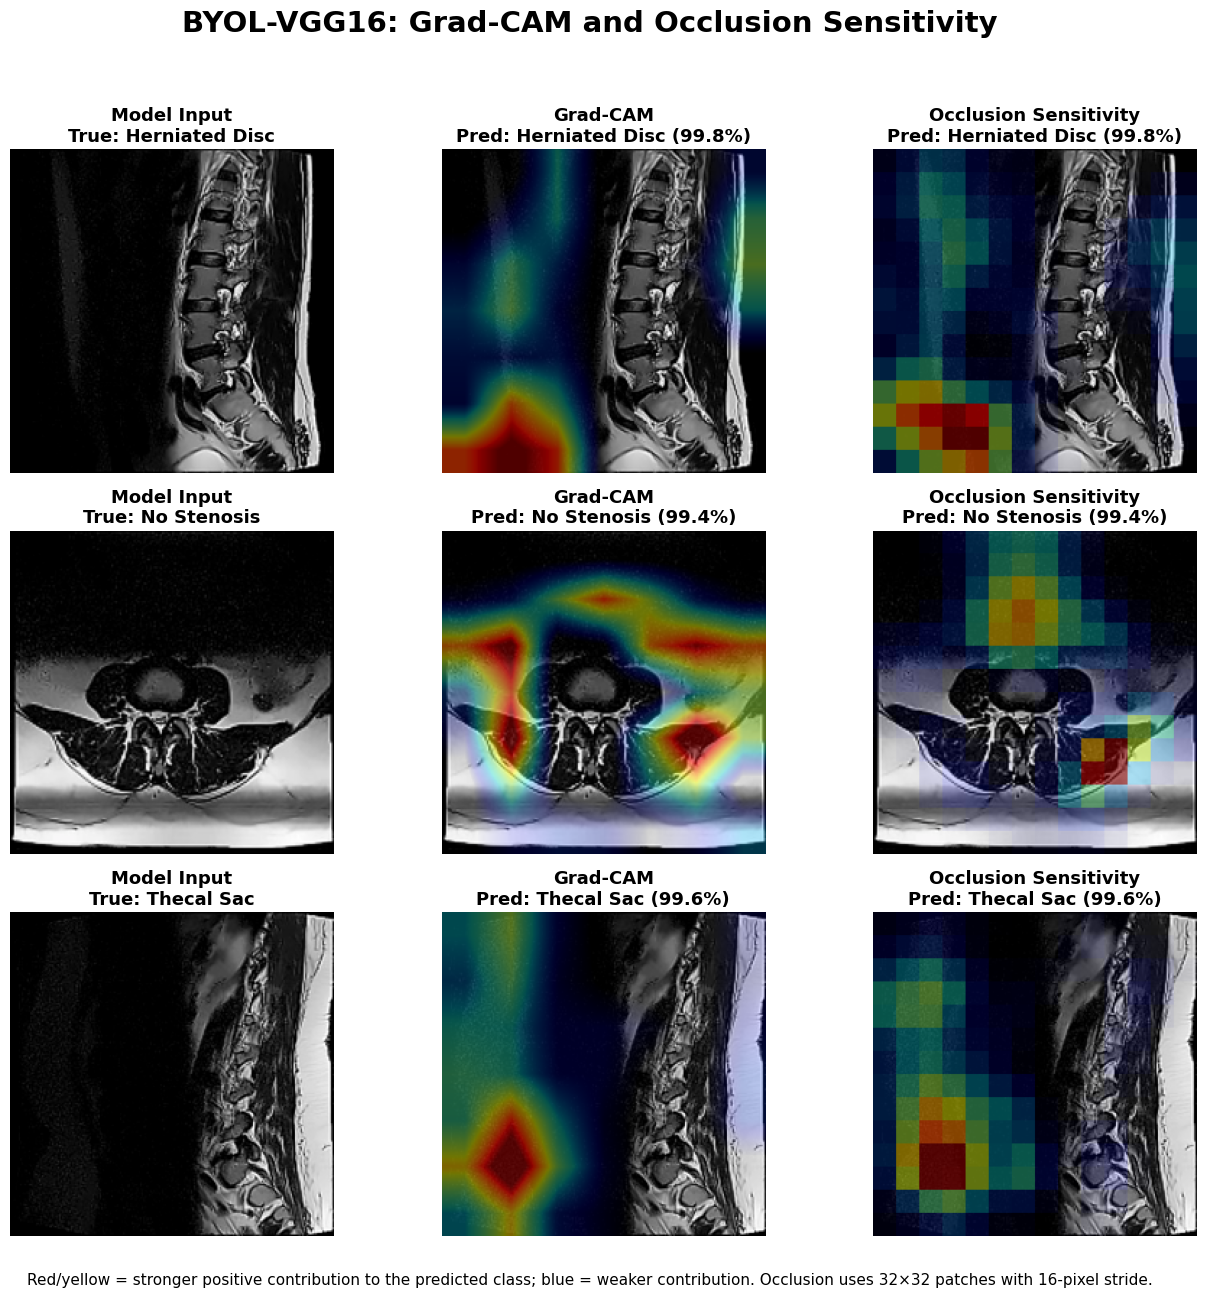


Explainability: BYOL-ResNet50


Selecting XAI samples:   0%|          | 0/41 [00:00<?, ?it/s]

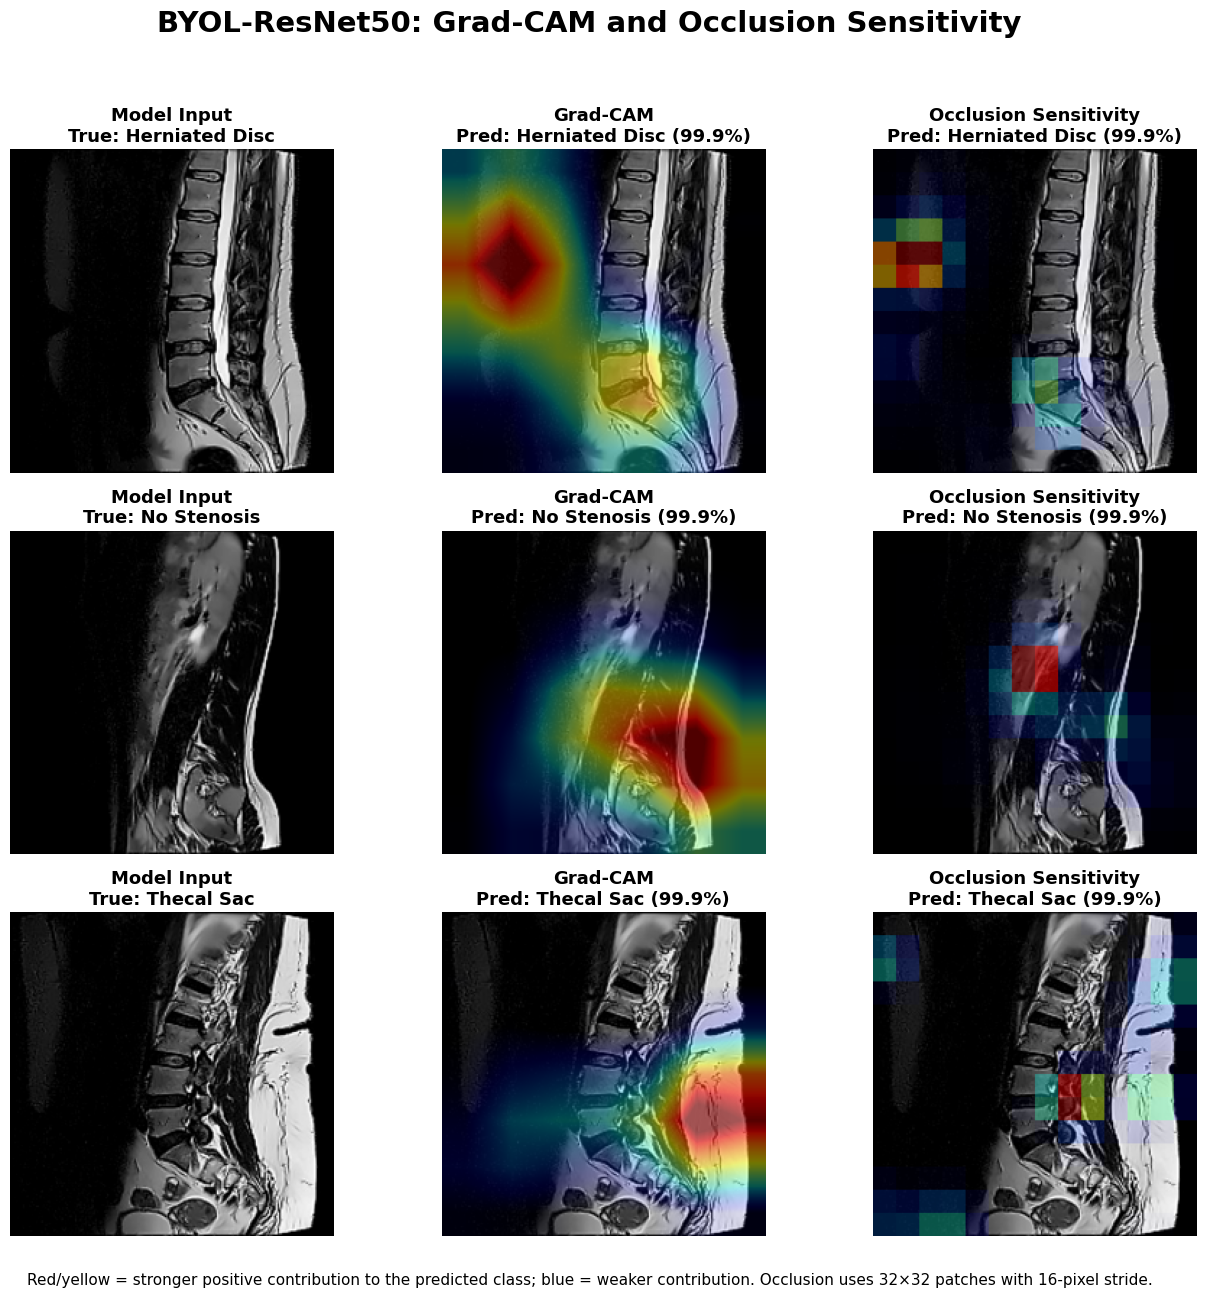


Explainability: BYOL-ConvNeXtSmall


Selecting XAI samples:   0%|          | 0/41 [00:00<?, ?it/s]

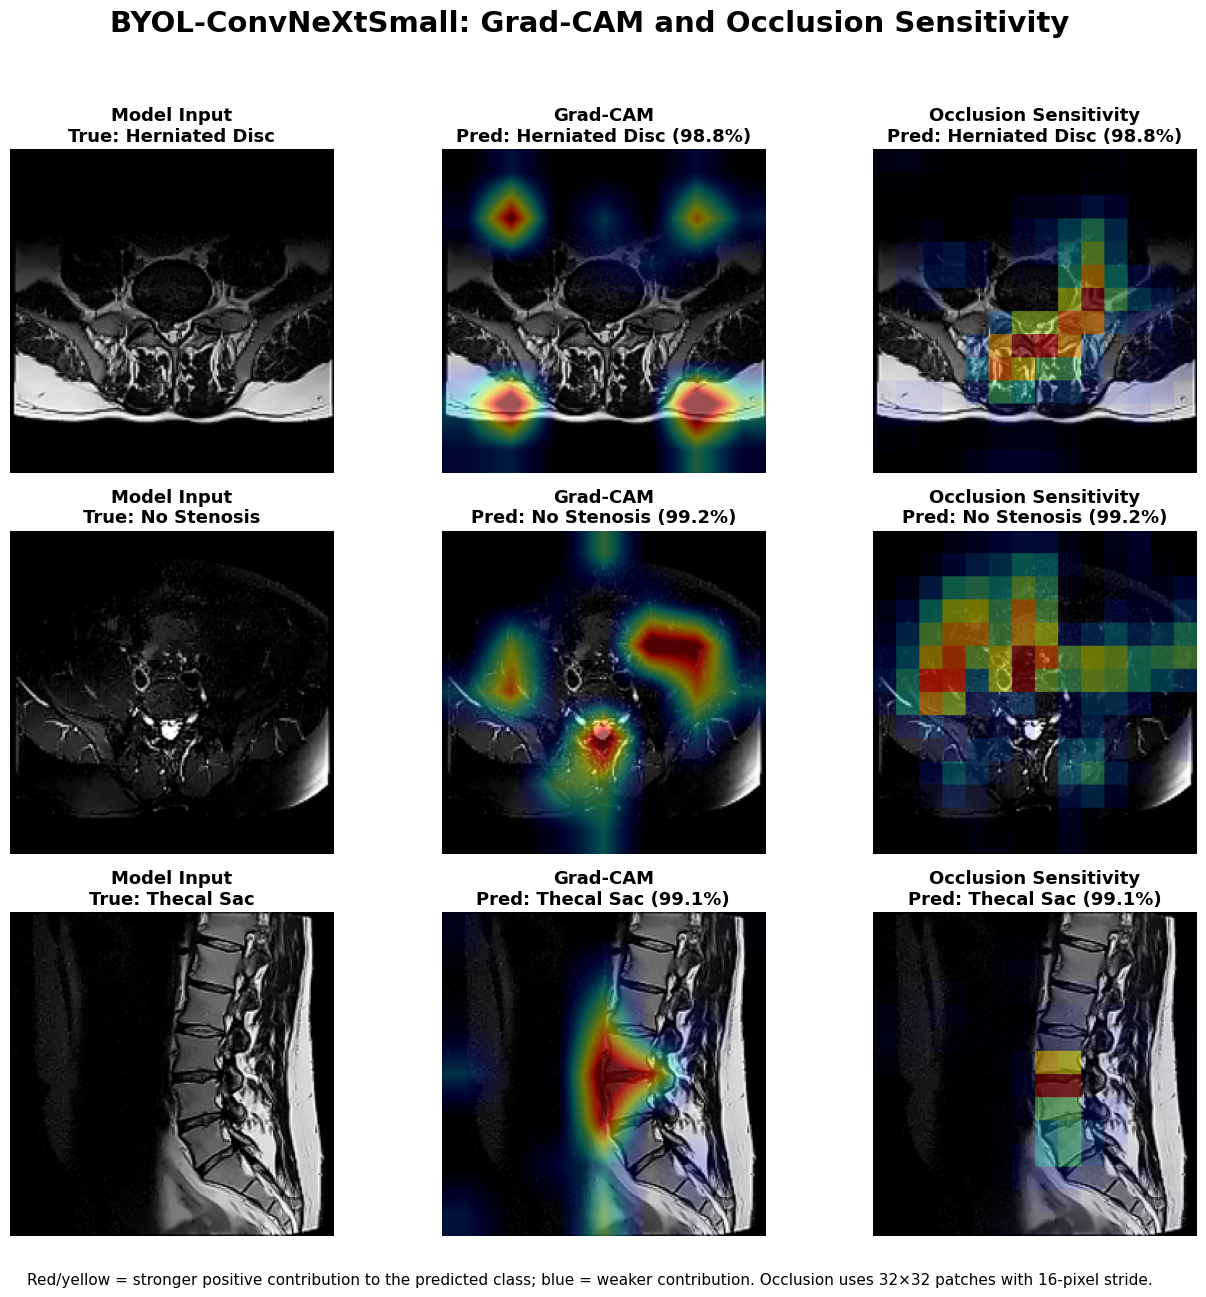

,model,class,predicted_label,confidence,selection_note
0,BYOL-VGG16,Herniated Disc,Herniated Disc,0.997759,highest_confidence_correct_example
1,BYOL-VGG16,No Stenosis,No Stenosis,0.994104,highest_confidence_correct_example
2,BYOL-VGG16,Thecal Sac,Thecal Sac,0.996046,highest_confidence_correct_example
3,BYOL-ResNet50,Herniated Disc,Herniated Disc,0.999479,highest_confidence_correct_example
4,BYOL-ResNet50,No Stenosis,No Stenosis,0.999393,highest_confidence_correct_example
5,BYOL-ResNet50,Thecal Sac,Thecal Sac,0.999130,highest_confidence_correct_example
6,BYOL-ConvNeXtSmall,Herniated Disc,Herniated Disc,0.987687,highest_confidence_correct_example
7,BYOL-ConvNeXtSmall,No Stenosis,No Stenosis,0.992017,highest_confidence_correct_example
8,BYOL-ConvNeXtSmall,Thecal Sac,Thecal Sac,0.990524,highest_confidence_correct_example


Explainability figures are saved in: /kaggle/working/lumbar_mri_byol_224_bs32_v1/paper_figures


In [16]:
XAI_OCCLUSION_PATCH = 32
XAI_OCCLUSION_STRIDE = 16
XAI_OCCLUSION_BATCH_SIZE = 32


def normalize_xai_map(values, eps=1e-8):
    values = np.asarray(values, dtype=np.float32)
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    values = np.maximum(values, 0.0)

    maximum = float(values.max()) if values.size else 0.0
    if maximum <= eps:
        return np.zeros_like(values, dtype=np.float32)

    positive = values[values > 0]
    if positive.size >= 8:
        lower = float(np.percentile(positive, 10))
        upper = float(np.percentile(positive, 99))
        if upper > lower + eps:
            values = np.clip((values - lower) / (upper - lower), 0.0, 1.0)
        else:
            values = values / maximum
    else:
        values = values / maximum

    return np.clip(values, 0.0, 1.0).astype(np.float32)


def tensor_to_display_image(image_tensor, mean, std):
    image = image_tensor.detach().cpu().float().permute(1, 2, 0).numpy()
    mean_array = np.asarray(mean, dtype=np.float32).reshape(1, 1, 3)
    std_array = np.asarray(std, dtype=np.float32).reshape(1, 1, 3)
    image = image * std_array + mean_array
    return np.clip(image, 0.0, 1.0)


def overlay_xai_heatmap(base_image, heatmap, alpha=0.58, cmap_name='jet'):
    base_image = np.asarray(base_image, dtype=np.float32)
    heatmap = normalize_xai_map(heatmap)

    color_map = plt.get_cmap(cmap_name)
    colored = color_map(heatmap)[..., :3].astype(np.float32)

    alpha_map = (alpha * np.power(heatmap, 0.65))[..., None]
    overlay = base_image * (1.0 - alpha_map) + colored * alpha_map
    return np.clip(overlay, 0.0, 1.0)


def load_model_for_xai(model_label):
    checkpoint_path = CHECKPOINT_DIR / f'{model_label.lower()}_byol_finetuned_best.pth'
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f'Missing fine-tuned checkpoint for {model_label}: {checkpoint_path}'
        )

    checkpoint = load_checkpoint(checkpoint_path, DEVICE)
    if checkpoint.get('experiment_id') != EXPERIMENT_ID:
        raise RuntimeError(
            f'Checkpoint experiment ID mismatch for {model_label}. '
            f"Found {checkpoint.get('experiment_id')}, expected {EXPERIMENT_ID}."
        )

    timm_name = checkpoint['timm_name']
    model = TransferClassifier(
        timm_name,
        len(class_names),
        pretrained=False,
    ).to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)
    model.eval()

    mean = tuple(checkpoint['mean'])
    std = tuple(checkpoint['std'])
    return model, mean, std


def predict_test_with_confidence(model, eval_transform):
    dataset = MRIFrameDataset(test_df, eval_transform)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
    )

    rows = []
    model.eval()

    with torch.no_grad():
        for images, labels, paths in tqdm(
            loader,
            leave=False,
            desc='Selecting XAI samples',
        ):
            images = images.to(DEVICE, non_blocking=True)

            with autocast_context(False):
                logits = model(images.float())
                probabilities = torch.softmax(logits.float(), dim=1)

            confidences, predictions = probabilities.max(dim=1)

            for label, prediction, confidence, path in zip(
                labels.tolist(),
                predictions.cpu().tolist(),
                confidences.cpu().tolist(),
                paths,
            ):
                rows.append({
                    'path': path,
                    'true_index': int(label),
                    'predicted_index': int(prediction),
                    'confidence': float(confidence),
                    'correct': int(label) == int(prediction),
                })

    return pd.DataFrame(rows)


def choose_representative_samples(prediction_frame):
    selected = []

    for class_index, class_name in enumerate(class_names):
        candidates = prediction_frame[
            (prediction_frame['true_index'] == class_index)
            & (prediction_frame['predicted_index'] == class_index)
        ].sort_values('confidence', ascending=False)

        if candidates.empty:
            fallback = prediction_frame[
                prediction_frame['true_index'] == class_index
            ].sort_values('confidence', ascending=False)

            if fallback.empty:
                raise RuntimeError(
                    f'No test image was available for class {class_name}.'
                )

            row = fallback.iloc[0].copy()
            row['selection_note'] = 'fallback_true_class_example'
        else:
            row = candidates.iloc[0].copy()
            row['selection_note'] = 'highest_confidence_correct_example'

        row['class_name'] = class_name
        selected.append(row)

    return pd.DataFrame(selected).reset_index(drop=True)


def gradcam_map(model, image_tensor, target_index=None):
    model.eval()
    inputs = image_tensor.unsqueeze(0).to(DEVICE).float()

    with torch.enable_grad():
        feature_maps = model.backbone.forward_features(inputs)

        if feature_maps.ndim != 4:
            raise RuntimeError(
                f'Grad-CAM requires a 4D convolutional feature map; '
                f'got shape {tuple(feature_maps.shape)}.'
            )

        pre_logits = model.backbone.forward_head(
            feature_maps,
            pre_logits=True,
        )
        logits = model.classifier(pre_logits)

        if target_index is None:
            target_index = int(logits.argmax(dim=1).item())

        target_score = logits[0, int(target_index)]
        gradients = torch.autograd.grad(
            outputs=target_score,
            inputs=feature_maps,
            retain_graph=False,
            create_graph=False,
            allow_unused=False,
        )[0]

        channel_weights = gradients.mean(
            dim=(2, 3),
            keepdim=True,
        )

        cam = torch.relu(
            (channel_weights * feature_maps).sum(
                dim=1,
                keepdim=True,
            )
        )

        cam = F.interpolate(
            cam,
            size=(INPUT_SIZE, INPUT_SIZE),
            mode='bilinear',
            align_corners=False,
        )

    cam = cam[0, 0].detach().cpu().numpy()
    return normalize_xai_map(cam), int(target_index)


def _occlusion_positions(length, patch_size, stride):
    patch_size = min(int(patch_size), int(length))
    positions = list(
        range(
            0,
            max(length - patch_size, 0) + 1,
            int(stride),
        )
    )

    last = length - patch_size
    if not positions or positions[-1] != last:
        positions.append(last)

    return positions


def occlusion_sensitivity_map(
    model,
    image_tensor,
    target_index=None,
    patch_size=XAI_OCCLUSION_PATCH,
    stride=XAI_OCCLUSION_STRIDE,
    batch_size=XAI_OCCLUSION_BATCH_SIZE,
):
    model.eval()
    inputs = image_tensor.unsqueeze(0).to(DEVICE).float()

    with torch.no_grad():
        base_logits = model(inputs)
        base_probabilities = torch.softmax(
            base_logits.float(),
            dim=1,
        )

    if target_index is None:
        target_index = int(base_probabilities.argmax(dim=1).item())

    base_probability = float(
        base_probabilities[0, int(target_index)].item()
    )

    height, width = image_tensor.shape[-2:]
    y_positions = _occlusion_positions(
        height,
        patch_size,
        stride,
    )
    x_positions = _occlusion_positions(
        width,
        patch_size,
        stride,
    )

    coordinates = [
        (top, left)
        for top in y_positions
        for left in x_positions
    ]

    score_sum = np.zeros(
        (height, width),
        dtype=np.float32,
    )
    score_count = np.zeros(
        (height, width),
        dtype=np.float32,
    )

    for start in range(0, len(coordinates), batch_size):
        batch_coordinates = coordinates[
            start:start + batch_size
        ]

        occluded_batch = inputs.repeat(
            len(batch_coordinates),
            1,
            1,
            1,
        )

        for item_index, (top, left) in enumerate(
            batch_coordinates
        ):
            bottom = min(top + patch_size, height)
            right = min(left + patch_size, width)

            occluded_batch[
                item_index,
                :,
                top:bottom,
                left:right,
            ] = 0.0

        with torch.no_grad():
            logits = model(occluded_batch)
            probabilities = torch.softmax(
                logits.float(),
                dim=1,
            )[:, int(target_index)]

        probability_drops = (
            base_probability
            - probabilities.detach().cpu().numpy()
        )

        for (top, left), probability_drop in zip(
            batch_coordinates,
            probability_drops,
        ):
            bottom = min(top + patch_size, height)
            right = min(left + patch_size, width)

            positive_drop = max(
                float(probability_drop),
                0.0,
            )

            score_sum[
                top:bottom,
                left:right,
            ] += positive_drop

            score_count[
                top:bottom,
                left:right,
            ] += 1.0

        del occluded_batch, logits, probabilities

    sensitivity = score_sum / np.maximum(
        score_count,
        1.0,
    )

    return (
        normalize_xai_map(sensitivity),
        int(target_index),
        base_probability,
    )


def create_xai_panel(model_label):
    model, mean, std = load_model_for_xai(model_label)
    _, eval_transform = make_transforms(mean, std)

    prediction_frame = predict_test_with_confidence(
        model,
        eval_transform,
    )
    selected_frame = choose_representative_samples(
        prediction_frame
    )

    figure, axes = plt.subplots(
        len(class_names),
        3,
        figsize=(13.5, 13.0),
    )

    xai_rows = []

    for row_index, sample in selected_frame.iterrows():
        path = sample['path']

        with Image.open(path) as image:
            image = image.copy()

        image_tensor = eval_transform(image)

        predicted_index = int(
            sample['predicted_index']
        )

        gradcam, gradcam_target = gradcam_map(
            model,
            image_tensor,
            target_index=predicted_index,
        )

        occlusion, occlusion_target, base_probability = (
            occlusion_sensitivity_map(
                model,
                image_tensor,
                target_index=predicted_index,
            )
        )

        display_image = tensor_to_display_image(
            image_tensor,
            mean,
            std,
        )

        gradcam_overlay = overlay_xai_heatmap(
            display_image,
            gradcam,
            alpha=0.62,
            cmap_name='jet',
        )

        occlusion_overlay = overlay_xai_heatmap(
            display_image,
            occlusion,
            alpha=0.62,
            cmap_name='jet',
        )

        axes[row_index, 0].imshow(display_image)
        axes[row_index, 1].imshow(gradcam_overlay)
        axes[row_index, 2].imshow(occlusion_overlay)

        for column in range(3):
            axes[row_index, column].axis('off')

        class_label = sample['class_name']
        predicted_label = class_names[predicted_index]
        confidence = float(sample['confidence'])

        axes[row_index, 0].set_ylabel(
            class_label,
            fontsize=15,
            fontweight='bold',
            rotation=90,
            labelpad=13,
        )

        axes[row_index, 0].set_title(
            f'Model Input\nTrue: {class_label}',
            fontsize=13,
            fontweight='bold',
        )

        axes[row_index, 1].set_title(
            f'Grad-CAM\nPred: {predicted_label} ({confidence:.1%})',
            fontsize=13,
            fontweight='bold',
        )

        axes[row_index, 2].set_title(
            f'Occlusion Sensitivity\nPred: {predicted_label} ({base_probability:.1%})',
            fontsize=13,
            fontweight='bold',
        )

        xai_rows.append({
            'model': f'BYOL-{model_label}',
            'class': class_label,
            'path': path,
            'true_label': class_label,
            'predicted_label': predicted_label,
            'confidence': confidence,
            'gradcam_target': class_names[gradcam_target],
            'occlusion_target': class_names[occlusion_target],
            'occlusion_base_probability': base_probability,
            'selection_note': sample['selection_note'],
            'gradcam_max': float(gradcam.max()),
            'occlusion_max': float(occlusion.max()),
        })

    figure.suptitle(
        f'BYOL-{model_label}: Grad-CAM and Occlusion Sensitivity',
        fontsize=21,
        fontweight='bold',
        y=0.995,
    )

    figure.text(
        0.5,
        0.012,
        'Red/yellow = stronger positive contribution to the predicted class; '
        'blue = weaker contribution. Occlusion uses 32×32 patches with 16-pixel stride.',
        ha='center',
        va='bottom',
        fontsize=11,
    )

    figure.tight_layout(
        rect=[0.02, 0.04, 1.0, 0.965]
    )

    save_figure(
        figure,
        f'xai_gradcam_occlusion_byol_{model_label.lower()}',
    )
    plt.show()

    pd.DataFrame(xai_rows).to_csv(
        TABLE_DIR / f'xai_representative_samples_byol_{model_label.lower()}.csv',
        index=False,
    )

    model.to('cpu')
    del model
    gc.collect()

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    return xai_rows


all_xai_rows = []

for model_label in MODELS_TO_RUN:
    print('\n' + '=' * 88)
    print(f'Explainability: BYOL-{model_label}')
    print('=' * 88)

    try:
        rows = create_xai_panel(model_label)
        all_xai_rows.extend(rows)
    except FileNotFoundError as error:
        print(f'Skipped {model_label}: {error}')


xai_summary = pd.DataFrame(all_xai_rows)

if not xai_summary.empty:
    xai_summary.to_csv(
        TABLE_DIR / 'xai_gradcam_occlusion_summary.csv',
        index=False,
    )
    display(
        xai_summary[
            [
                'model',
                'class',
                'predicted_label',
                'confidence',
                'selection_note',
            ]
        ]
    )

print(
    'Explainability figures are saved in:',
    FIGURE_DIR,
)


## Export Paper Assets

In [17]:
run_summary = {
    'dataset': 'Lumbar Spinal MRI Dataset',
    'archive': str(ARCHIVE_PATH),
    'classes': class_names,
    'original_images': int(len(raw_df)),
    'retained_unique_images': int(len(cleaned_df)),
    'training_images': int(len(train_df)),
    'validation_images': int(len(val_df)),
    'test_images': int(len(test_df)),
    'split': {'train': TRAIN_RATIO, 'validation': VAL_RATIO, 'test': TEST_RATIO},
    'input_size': INPUT_SIZE,
    'method': METHOD_NAME,
    'pretrained_init': PRETRAINED_INIT,
    'byol_pretrain_epochs': BYOL_PRETRAIN_EPOCHS,
    'byol_batch_size': BYOL_BATCH_SIZE,
    'byol_base_momentum': BYOL_BASE_MOMENTUM,
    'byol_hidden_dim': BYOL_HIDDEN_DIM,
    'byol_projection_dim': BYOL_PROJECTION_DIM,
    'finetune_batch_size': BATCH_SIZE,
    'head_epochs': HEAD_EPOCHS,
    'fine_tune_epochs': FINE_TUNE_EPOCHS,
    'seed': SEED,
    'models': MODEL_SPECS,
    'preprocessing': [
        'foreground-aware crop',
        'robust 1st-99th percentile intensity normalization',
        'square padding',
        'three-channel conversion',
        '224x224 bicubic resizing',
        'BYOL stage: RandomResizedCrop + flip + affine + color jitter + asymmetric blur/solarize',
        'fine-tune stage: mild training-only affine and intensity augmentation',
        'pretrained-model normalization',
    ],
    'labeled_unlabeled_protocol': (
        'BYOL pretraining uses only train-split images with labels discarded. '
        'Validation/test are untouched until fine-tuning/evaluation respectively.'
    ),
    'patient_level_split_available': False,
}

(OUTPUT_DIR / 'run_summary.json').write_text(json.dumps(run_summary, indent=2))

readme = '\n'.join([
    'Lumbar Spinal MRI Classification — BYOL Self-Supervised Study',
    '',
    f'Original images: {len(raw_df):,}',
    f'Unique retained images: {len(cleaned_df):,}',
    f'Training images: {len(train_df):,}',
    f'Validation images: {len(val_df):,}',
    f'Test images: {len(test_df):,}',
    f"Classes: {', '.join(class_names)}",
    f"Models: {', '.join('BYOL-' + m for m in MODELS_TO_RUN)}",
    f'Input size: {INPUT_SIZE} x {INPUT_SIZE}',
    f'BYOL pretrain epochs: {BYOL_PRETRAIN_EPOCHS}',
    f'BYOL initialized from ImageNet weights: {PRETRAINED_INIT}',
    f'Head training epochs: {HEAD_EPOCHS}',
    f'Fine-tuning epochs: {FINE_TUNE_EPOCHS}',
    '',
    'The dataset does not expose patient identifiers. The requested split is image-level. '
    'Exact duplicate images are removed before splitting. BYOL pretraining uses only the '
    'training-split images with labels discarded (self-supervised); labels are used only '
    'in the subsequent fine-tuning stage.',
])

(OUTPUT_DIR / 'README.txt').write_text(readme)

paper_zip = Path('/kaggle/working/lumbar_spinal_mri_byol_paper_assets.zip')

with zipfile.ZipFile(paper_zip, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    for folder in [FIGURE_DIR, TABLE_DIR]:
        for path in folder.rglob('*'):
            if path.is_file():
                archive.write(path, path.relative_to(OUTPUT_DIR))

    archive.write(OUTPUT_DIR / 'README.txt', 'README.txt')
    archive.write(OUTPUT_DIR / 'run_summary.json', 'run_summary.json')

print(f'Figures: {FIGURE_DIR}')
print(f'Tables: {TABLE_DIR}')
print(f'Checkpoints: {CHECKPOINT_DIR}')
print(f'Paper assets ZIP: {paper_zip}')


Figures: /kaggle/working/lumbar_mri_byol_224_bs32_v1/paper_figures
Tables: /kaggle/working/lumbar_mri_byol_224_bs32_v1/tables
Checkpoints: /kaggle/working/lumbar_mri_byol_224_bs32_v1/checkpoints
Paper assets ZIP: /kaggle/working/lumbar_spinal_mri_byol_paper_assets.zip
